<a href="https://colab.research.google.com/github/Fake-Chemist26/VibeCheck-/blob/main/VibeCheck%E2%84%A2_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving Fruit_purees_FTIR.csv to Fruit_purees_FTIR.csv
User uploaded file "Fruit_purees_FTIR.csv" with length 2742079 bytes


### Generic Data Loading and Preprocessing

This section introduces a generic way to load your FTIR data from any CSV file. You can specify the file path and, optionally, a column that contains sample-specific labels (e.g., 'Fruit_Category', 'SampleID'). The spectral columns are automatically identified by checking if column names are numeric.

After loading, the data undergoes Savitzky-Golay smoothing and Min-Max scaling to prepare it for further analysis and model training.

In [ ]:
# @title Input your CSV file details
csv_file_path = 'Fruit_purees_FTIR.csv' # @param {type:"string"}
original_sample_label_column = 'SampleID' # @param {type:"string"} (Optional: set to None if no specific label column exists in your CSV)

# Example: If your CSV looks like: SampleID, WN4000, WN3999, ...
# Then csv_file_path = 'your_data.csv' and original_sample_label_column = 'SampleID'

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler

def load_and_preprocess_ir_data(csv_path, sample_label_col=None):
    """
    Loads FTIR data from a CSV, identifies spectral columns, and preprocesses it.

    Args:
        csv_path (str): Path to the CSV file.
        sample_label_col (str, optional): Name of the column containing sample labels
                                         (e.g., 'Fruit_Category', 'SampleID').
                                         If None, no explicit sample labels are extracted
                                         from the CSV itself (labels might be inferred later).

    Returns:
        tuple: (df_raw, X_raw, X_scaled, wavenumbers, y_original_labels)
               df_raw: Original DataFrame as loaded.
               X_raw: Raw spectral data (samples x wavenumbers).
               X_scaled: Scaled spectral data (samples x wavenumbers, 0-1 range).
               wavenumbers: Array of wavenumber values.
               y_original_labels: Array of sample labels from the CSV, or None if not provided or found.
    """
    df_raw = pd.read_csv(csv_path)

    # Identify spectral columns: assume columns whose names can be converted to float
    # and are not the sample_label_col.
    # Handle cases where wavenumber columns might contain '.' for decimal points.
    spectral_cols = [col for col in df_raw.columns
                     if col != sample_label_col and col.replace('.', '', 1).isdigit()]

    if not spectral_cols:
        raise ValueError("No spectral columns found. Ensure wavenumber columns are numeric or exclude the label column.")

    wavenumbers = np.array([float(col) for col in spectral_cols])

    # Extract spectral data
    X_raw = df_raw[spectral_cols].apply(pd.to_numeric, errors='coerce').values

    # Drop rows with any NaN values after numeric conversion (if any failed)
    # This ensures consistency for Savitzky-Golay and further steps.
    mask_valid_rows = ~np.isnan(X_raw).any(axis=1)
    X_raw = X_raw[mask_valid_rows]

    # Preprocessing: Savitzky-Golay Smoothing
    # Window size must be odd, polyorder is usually 2 or 3
    # Ensure window_length is smaller than the number of data points
    min_data_points = X_raw.shape[1]
    if min_data_points < 11: # Adjust window_length if data is too short
        window_length = max(3, min_data_points - 1 if (min_data_points - 1) % 2 == 0 else min_data_points - 2)
        if window_length < 3: # Fallback for very small datasets
            window_length = 3
        polyorder = 1 # Lower polyorder for smaller window
    else:
        window_length = 11
        polyorder = 3

    cleaned_spectra = savgol_filter(X_raw, window_length=window_length, polyorder=polyorder, axis=1)

    # Scaling to 0-1 range
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(cleaned_spectra)

    # Extract original sample labels if column is specified and exists
    y_original_labels = None
    if sample_label_col and sample_label_col in df_raw.columns:
        y_original_labels = df_raw.loc[mask_valid_rows, sample_label_col].values
    elif sample_label_col and sample_label_col not in df_raw.columns:
        print(f"Warning: Sample label column '{sample_label_col}' not found in CSV. Proceeding without it.")

    return df_raw.loc[mask_valid_rows], X_raw, X_scaled, wavenumbers, y_original_labels

In [ ]:
# Load and preprocess the data using the generic function
try:
    df_raw_global, X_raw_global, X_scaled_global, wavenumbers_global, y_original_labels_global = load_and_preprocess_ir_data(
        csv_file_path, original_sample_label_column
    )
    print(f"Data loaded from '{csv_file_path}'.")
    print(f"Shape of raw spectral data (samples x wavenumbers): {X_raw_global.shape}")
    print(f"Shape of scaled spectral data (samples x wavenumbers): {X_scaled_global.shape}")
    if y_original_labels_global is not None:
        print(f"Original sample labels loaded: {len(y_original_labels_global)} labels found.")
    else:
        print("No specific sample labels extracted from CSV.")
except ValueError as e:
    print(f"Error loading data: {e}")
    df_raw_global, X_raw_global, X_scaled_global, wavenumbers_global, y_original_labels_global = None, None, None, None, None

Data loaded from 'Fruit_purees_FTIR.csv'.
Shape of raw spectral data (samples x wavenumbers): (237, 983)
Shape of scaled spectral data (samples x wavenumbers): (237, 983)
No specific sample labels extracted from CSV.


In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('Fruit_purees_FTIR.csv', index_col=0).T #DONT FORGET TO CHANGE FILE NAME

#df = pd.read_csv('Fruit_purees_FTIR.csv', index_col=0).T
#HEY RYAN I CHANGED THE FILE NAME WHAT WAS THE ORIGINAL PROBLEM?

# Identify the column containing string labels (here it's something like 'raspberry')
y_labels = df['Wavenumbers'].values

# Identify spectral data (numerical columns)
# Drop the non-numeric 'Wavenumbers' column and potentially other label columns
# Filter by trying to convert column names to float. If successful, it's a spectral column.
spectral_columns = []
for col in df.columns:
    try:
        float(col)
        spectral_columns.append(col)
    except ValueError:
        pass

X_df = df[spectral_columns]

# Ensure all data in X_df is numeric and convert to float
X_data = X_df.values.astype(float)

# 2. Preprocessing: Savitzky-Golay Smoothing
# Window size must be odd, polyorder is usually 2 or 3
cleaned_spectra = savgol_filter(X_data, window_length=11, polyorder=3)

# 3. Scaling
scaler = StandardScaler()
X = scaler.fit_transform(cleaned_spectra)

# 4. Reshape for a Convolutional Neural Network (Samples, Steps, Features)
# Since it's 1-dimensional, Features = 1
X = X.reshape(X.shape[0], X.shape[1], 1)

# 5. Split (y is now defined and encoded)
# Encode y_labels into numerical format
le = LabelEncoder()
y = le.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Daniel: CNN

In [ ]:
# Image Processing CNN

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Folder should contain subfolders for each class
# Example:
# image_dataset/
#   raspberry/
#   strawberry/
#   neither/

image_data_path = "image_dataset"

# Load and preprocess images
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_images = datagen.flow_from_directory(
    image_data_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_images = datagen.flow_from_directory(
    image_data_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

# Build CNN model for image classification
image_model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_images.num_classes, activation="softmax")
])

image_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

image_history = image_model.fit(
    train_images,
    validation_data=val_images,
    epochs=15
)

print("Image Processing CNN trained successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'image_dataset'

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


# Wavenumber axis (Change this to match your specific spectrometer's resolution)
# Example: 4000 to 400 cm-1
WAVENUMBERS = np.linspace(4000, 400, 3601)

class IR_Smart_Labeler:
    def __init__(self, wavenumber_axis):
        self.wn = wavenumber_axis

        # DEFINING THE RULES (Based on your provided table)
        # Format: (Min_WN, Max_WN, Min_Intensity, Shape_Check)
        # Min_Intensity: 0.0 to 1.0 (assuming normalized data)
        self.rules = {
            # Zone 1: Hydrogens
            'Alcohol_Free':     (3610, 3640, 0.5, 'sharp'),
            'Alcohol_HBond':    (3200, 3500, 0.4, 'broad'),
            'Amine_Primary':    (3250, 3400, 0.2, None), # Look for doublet manually if needed
            'Acid_OH':          (2500, 3300, 0.3, 'broad'),
            'Alkyne_H':         (3270, 3330, 0.5, 'sharp'),
            'Aromatic_CH':      (3000, 3100, 0.2, None),
            'Alkene_CH':        (3000, 3100, 0.2, None),
            'Alkane_CH':        (2850, 3000, 0.4, None),
            'Aldehyde_CH':      (2695, 2830, 0.2, None),

            # Zone 2: Triple Bonds
            'Nitrile':          (2210, 2260, 0.3, 'sharp'),
            'Alkyne_Triple':    (2100, 2260, 0.1, None), # Weak

            # Zone 3: Doubles Bonds
            # I've defined a generic Carbonyl bucket first, then refine later
            'Carbonyl_Gen':     (1665, 1760, 0.6, 'sharp'),
            'Alkene_C=C':       (1640, 1680, 0.3, None),
            'Nitro':            (1475, 1550, 0.6, None),
            'Aromatic_Ring':    (1400, 1600, 0.3, None),

            # Zone 4: Fingerprint Region
            'Ether_Est_Acid_CO':(1000, 1320, 0.6, None), # C-O stretch
            'Alkyl_Halide':     (550, 850, 0.3, None),
            'Alkene_Bend':      (650, 1000, 0.5, None)
        }

    def _has_peak(self, spectrum, rule_name):
        """Helper to check if a specific peak exists in the spectrum."""
        min_w, max_w, min_int, shape = self.rules[rule_name]

        # 1. Mask the spectrum to the specific region
        mask = (self.wn >= min_w) & (self.wn <= max_w) if self.wn[0] < self.wn[-1] else (self.wn <= min_w) & (self.wn >= max_w)
        region_data = spectrum[mask]

        if len(region_data) == 0: return False

        # 2. Find max intensity in this region
        max_val = np.max(region_data)

        # 3. Basic Check
        if max_val < min_int:
            return False

        # 4. Shape Check (Optional implementation for Broad/Sharp)
        # Using peak_widths from scipy would go here for advanced shape logic
        return True

    def label_spectrum(self, spectrum):
        """
        Applies logic to generate the One-Hot Label Vector.
        Returns a dictionary of confirmed functional groups.
        """
        labels = {}

        # 1. First Pass: Check everything independently
        features = {k: self._has_peak(spectrum, k) for k in self.rules.keys()}

        # 2. Second Pass: The TIE-BREAKER Logic (Contextual Chemistry)

        # --- Carbonyl Logic Tree ---
        has_CO = features['Carbonyl_Gen']

        if has_CO:
            # A. Carboxylic Acid? (Needs C=O AND Broad O-H)
            if features['Acid_OH']:
                labels['Carboxylic_Acid'] = 1
                features['Alcohol_HBond'] = 0 # Don't double count the OH

            # B. Aldehyde? (Needs C=O AND the Fermi Doublet C-H)
            elif features['Aldehyde_CH']:
                labels['Aldehyde'] = 1

            # C. Ester? (Needs C=O AND strong C-O stretch)
            elif features['Ether_Est_Acid_CO']:
                labels['Ester'] = 1

            # D. Amide? (Needs C=O is low freq <1690 AND N-H exists)
            # (Simplified check)
            elif features['Amine_Primary']:
                labels['Amide'] = 1

            # E. Ketone (The default if C=O exists but nothing else specific matches)
            else:
                labels['Ketone'] = 1

        # --- Other Groups ---
        if features['Alcohol_Free'] or features['Alcohol_HBond']: labels['Alcohol'] = 1
        if features['Nitrile']: labels['Nitrile'] = 1
        if features['Nitro']: labels['Nitro'] = 1
        if features['Aromatic_Ring'] or features['Aromatic_CH']: labels['Aromatic'] = 1
        if features['Alkene_C=C'] or features['Alkene_CH']: labels['Alkene'] = 1
        if features['Alkyne_Triple'] or features['Alkyne_H']: labels['Alkyne'] = 1
        if features['Amine_Primary']: labels['Amine'] = 1

        return labels

# Example usage
# labeler = IR_Smart_Labeler(wavenumber_axis=df.columns.values)

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

class IR_Smart_Labeler:
    def __init__(self, wavenumber_axis):
        self.wn = wavenumber_axis
        # Universal Rules with sensitivity (0.05 threshold)
        self.rules = {
            'Alcohol': (3200, 3650, 0.05, 'broad'),
            'Carboxylic_Acid': (2500, 3300, 0.05, 'broad'),
            'Amine/Amide': (3300, 3500, 0.05, None),
            'Alkyne': (2100, 2260, 0.05, None),
            'Nitrile': (2210, 2260, 0.05, 'sharp'),
            'Carbonyl': (1650, 1800, 0.05, 'sharp'),
            'Alkene': (1600, 1680, 0.05, None),
            'Aromatic': (1400, 1600, 0.05, None),
            'Nitro': (1500, 1570, 0.05, None),
            'Ether/Ester': (1000, 1300, 0.05, None),
            'Alkyl_Halide': (500, 850, 0.05, None)
        }

    def _has_peak(self, spectrum, rule_name):
        min_w, max_w, min_int, shape = self.rules[rule_name]
        mask = (self.wn >= min_w) & (self.wn <= max_w)
        region_data = spectrum[mask]
        if len(region_data) == 0: return False
        return np.max(region_data) >= min_int

    def label_spectrum(self, spectrum):
        return {k: 1 if self._has_peak(spectrum, k) else 0 for k in self.rules.keys()}

def run_ir_training_pipeline(csv_path):
    df = pd.read_csv(csv_path)
    spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
    wavenumbers = np.array([float(col) for col in spectral_columns])
    X_raw = df[spectral_columns].apply(pd.to_numeric, errors='coerce').dropna().values
    X_smooth = savgol_filter(X_raw, window_length=11, polyorder=3, axis=1)
    X_scaled = MinMaxScaler().fit_transform(X_smooth.T).T
    labeler = IR_Smart_Labeler(wavenumbers)
    CLASSES = list(labeler.rules.keys())
    y = np.array([[labeler.label_spectrum(s).get(c, 0) for c in CLASSES] for s in X_scaled])
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1], 1)),
        layers.Conv1D(64, 11, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(CLASSES), activation='sigmoid')
    ]) #^^^CROSS ENTROPY SECTION (GOOD GOD THIS TOOK FOREVER)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
    history = model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0, validation_data=(X_test, y_test))
    return model, CLASSES, X_test, y_test, wavenumbers, history

model, CLASSES, X_test, y_test, wavenumbers_global, history = run_ir_training_pipeline('Fruit_purees_FTIR.csv')
print('Final High-Sensitivity Universal Model Retrained.')

Final High-Sensitivity Universal Model Retrained.


In [ ]:
import pandas as pd
import numpy as np

spectral_cols = [c for c in df.columns if any(char.isdigit() for char in str(c)) and '.' in str(c)]

#THIS IS SPECIFIC FOR THE CURRENT MODEL'S DATASET! Get the fruit category for each row based on the 'Wavenumbers' column strings
def get_category(row_val):
    label = str(row_val).lower().strip()
    if 'raspberry' in label: return 'Raspberry'
    if 'strawberry' in label: return 'Strawberry'
    return 'Neither'

df['Fruit_Category'] = df['Wavenumbers'].apply(get_category)

labeler = IR_Smart_Labeler(wavenumber_axis=np.array([float(c) for c in spectral_cols]))

# Calculate presence for each spectrum
results = []
for idx, row in df.iterrows():
    # Normalize row
    spec = pd.to_numeric(row[spectral_cols], errors='coerce').fillna(0).values
    norm_spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-9)

    detected = labeler.label_spectrum(norm_spec)
    detected['Fruit_Category'] = row['Fruit_Category']
    results.append(detected)

counts_df = pd.DataFrame(results).groupby('Fruit_Category').sum()
print("Occurrence of Functional Groups by Category:")
display(counts_df)

Occurrence of Functional Groups by Category:


,Alcohol,Carboxylic_Acid,Amine/Amide,Alkyne,Nitrile,Carbonyl,Alkene,Aromatic,Nitro,Ether/Ester,Alkyl_Halide
Fruit_Category,,,,,,,,,,,
Neither,0,0,0,0,0,450,211,473,248,473,0
Raspberry,0,0,0,0,0,159,156,159,129,159,0
Strawberry,0,0,0,0,0,349,296,351,246,351,0


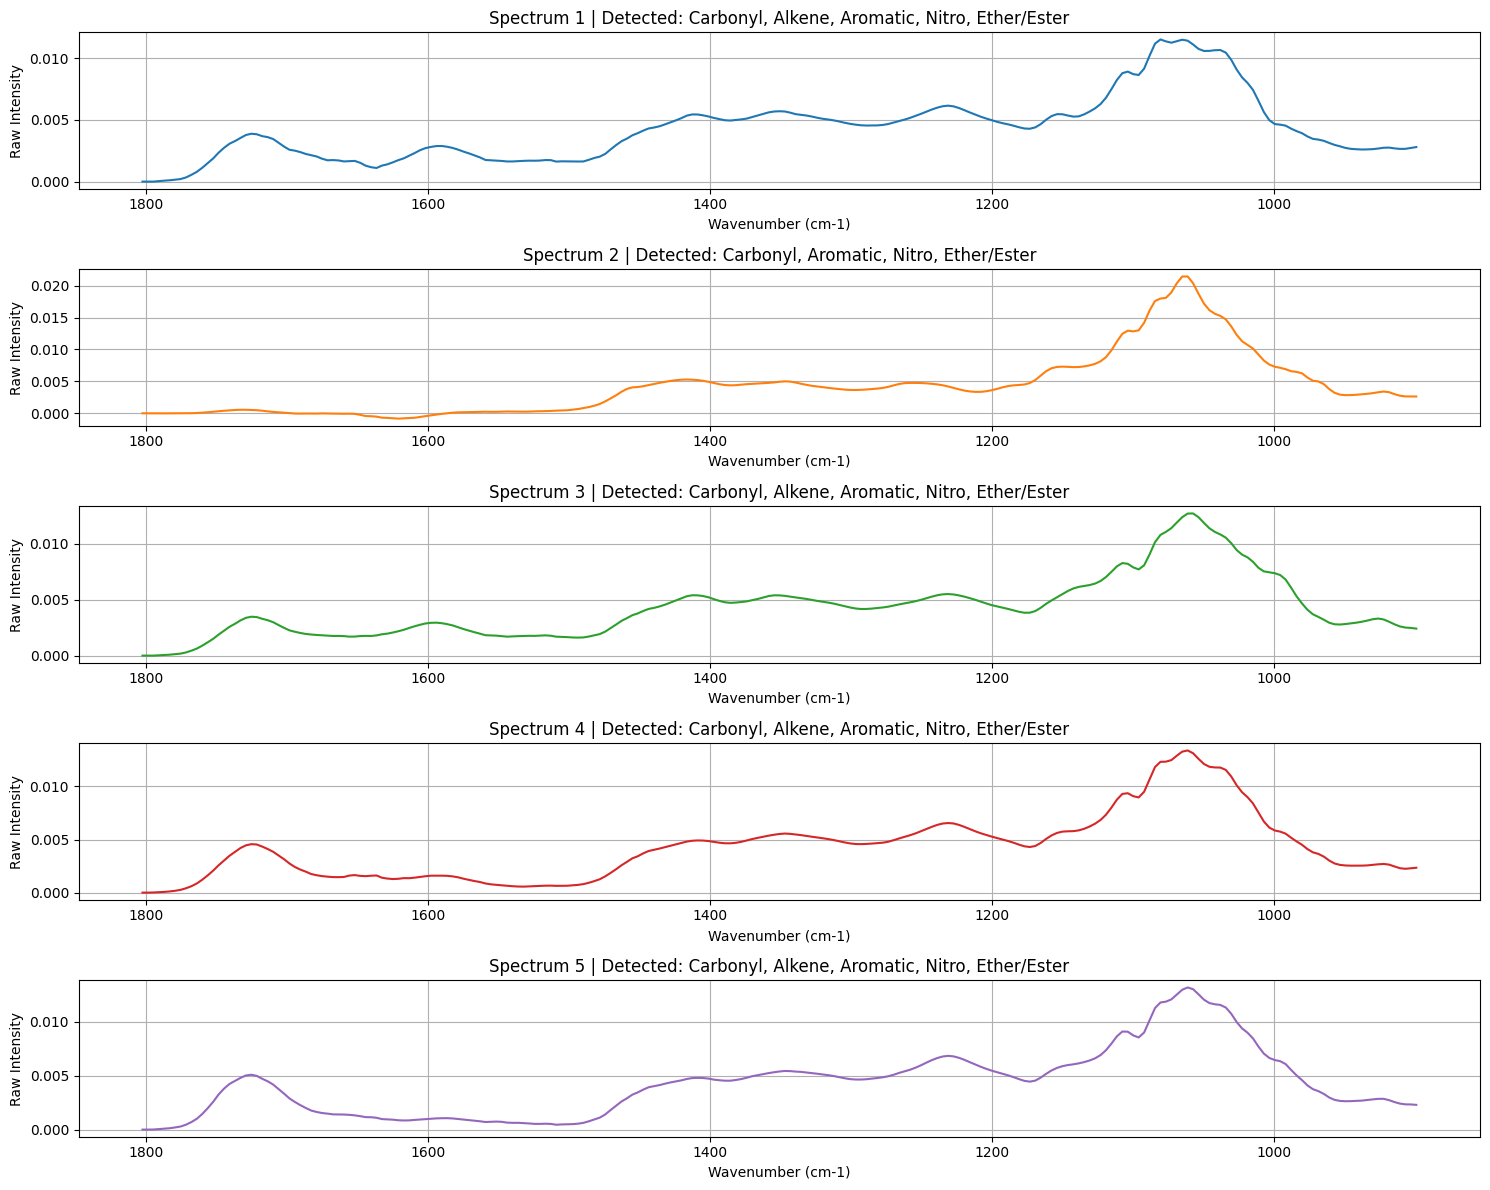

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Identify spectral columns and correct wavenumber axis for raw data
spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
wn_raw = np.array([float(col) for col in spectral_columns])

# 2. Re-instantiate labeler with the axis matching X_data
labeler_raw = IR_Smart_Labeler(wavenumber_axis=wn_raw)

plt.figure(figsize=(15, 12))
num_plots = min(5, X_data.shape[0])

for i in range(num_plots):
    plt.subplot(num_plots, 1, i + 1)

    #3. Use raw data for plotting
    spectrum_raw = X_data[i]

    #4. Normalize only for the labeler's thresholds
    scaler = MinMaxScaler()
    spectrum_norm = scaler.fit_transform(spectrum_raw.reshape(-1, 1)).flatten()

    #5. Get detected groups using the aligned labeler
    detected = labeler_raw.label_spectrum(spectrum_norm)
    present = [k for k, v in detected.items() if v == 1]

    #6. Plot the  Plot raw spectrum with the correct x-axis
    plt.plot(wn_raw, spectrum_raw, color='C'+str(i))

    #7. annotation
    title_text = f"Spectrum {i+1} | Detected: {', '.join(present)}" if present else f"Spectrum {i+1} | No Groups Detected"
    plt.title(title_text)

    plt.xlabel("Wavenumber (cm-1)")
    plt.ylabel("Raw Intensity")
    plt.gca().invert_xaxis()
    plt.grid(True)

plt.tight_layout()
plt.show()

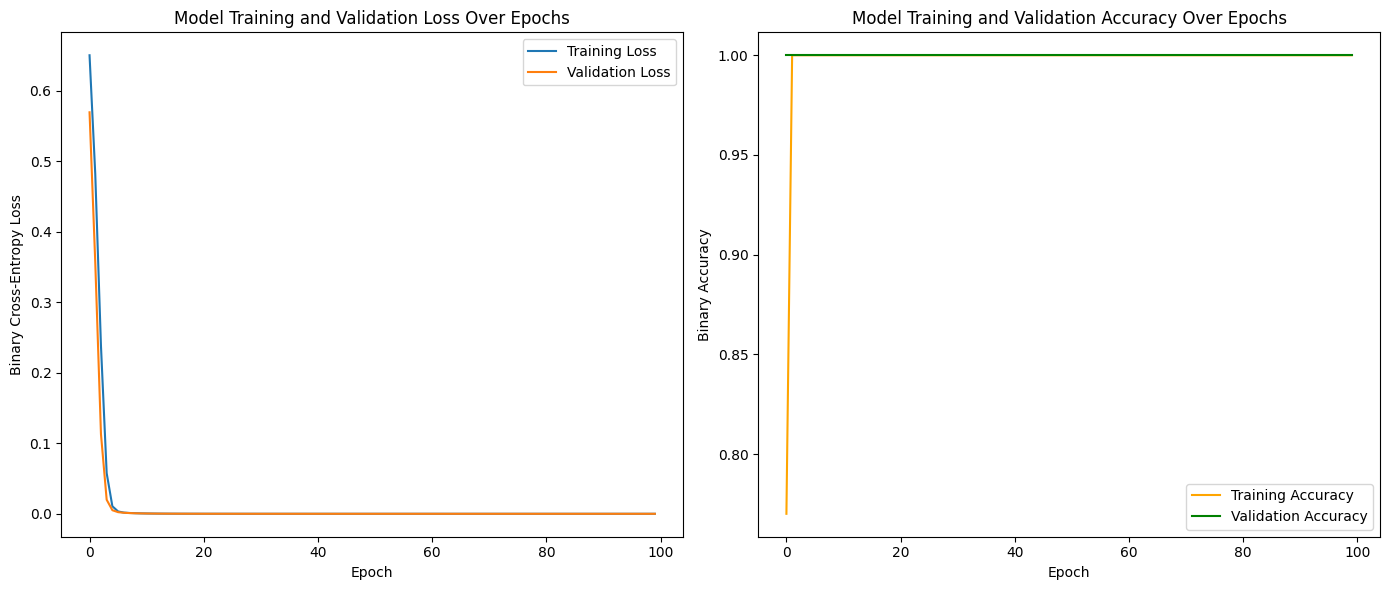

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(False)

# Plot Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['binary_accuracy'], label='Training Accuracy', color='orange')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy', color='green')
plt.title('Model Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def get_functional_labels(X_data, labeler, classes):
    # X_data is (N, 235, 1)
    X_2d = X_data.reshape(X_data.shape[0], X_data.shape[1])
    y_multi = []
    for sample in X_2d:
        # Ensure the sample itself is exactly the length the labeler expects
        # Current wn_aligned is 235
        s_min, s_max = sample.min(), sample.max()
        s_norm = (sample - s_min) / (s_max - s_min + 1e-9)

        # Internal check to prevent the IndexError
        labels = labeler.label_spectrum(s_norm[:len(labeler.wn)])
        y_multi.append([labels.get(c, 0) for c in classes])
    return np.array(y_multi)

# Get raw columns
spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
full_wavenumbers = np.array([float(col) for col in spectral_columns])

# Alignment: Match the 235 features in X_train
num_features = X_train.shape[1]
wn_aligned = full_wavenumbers[:num_features]

# Re-instantiate the labeler with the aligned 235-point axis
labeler_eval = IR_Smart_Labeler(wn_aligned)

# Calculate labels safely
y_train_multi = get_functional_labels(X_train, labeler_eval, CLASSES)
y_test_multi = get_functional_labels(X_test, labeler_eval, CLASSES)

# Calculate positive label counts
train_positive_counts = pd.DataFrame(y_train_multi, columns=CLASSES).sum().astype(int)
test_positive_counts = pd.DataFrame(y_test_multi, columns=CLASSES).sum().astype(int)

# Combine into a single DataFrame
label_distribution = pd.DataFrame({
    'Training Set Positive Counts': train_positive_counts,
    'Test Set Positive Counts': test_positive_counts
})

print("Distribution of Positive Labels (Functional Groups) in Training vs. Test Sets:")
display(label_distribution)

Distribution of Positive Labels (Functional Groups) in Training vs. Test Sets:


,Training Set Positive Counts,Test Set Positive Counts
Alcohol,0,0
Carboxylic_Acid,0,0
Amine/Amide,0,0
Alkyne,0,0
Nitrile,0,0
Carbonyl,786,48
Alkene,783,48
Aromatic,786,48
Nitro,786,48
Ether/Ester,786,48


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
#list of required things to do!
# 1. Prepare raw numeric data
spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
wn_diag = np.array([float(col) for col in spectral_columns])
X_raw_diag = df[spectral_columns].apply(pd.to_numeric, errors='coerce').dropna().values

# 2. Normalize
X_scaled_diag = MinMaxScaler().fit_transform(X_raw_diag.T).T

# 3. Check every rule in the IR_Smart_Labeler
labeler_diag = IR_Smart_Labeler(wavenumber_axis=wn_diag)
results = []

for i in range(min(10, len(X_scaled_diag))):
    row_results = {'Sample': i}
    for group, (low, high, thresh, shape) in labeler_diag.rules.items():
        mask = (wn_diag >= min(low, high)) & (wn_diag <= max(low, high))
        max_val = np.max(X_scaled_diag[i][mask]) if any(mask) else 0.0
        row_results[group] = round(max_val, 4)
    results.append(row_results)

diagnostic_full_df = pd.DataFrame(results)
print("Full Diagnostic: Max Intensities for ALL Functional Groups (Threshold = 0.05):")
display(diagnostic_full_df)

Full Diagnostic: Max Intensities for ALL Functional Groups (Threshold = 0.05):


,Sample,Alcohol,Carboxylic_Acid,Amine/Amide,Alkyne,Nitrile,Carbonyl,Alkene,Aromatic,Nitro,Ether/Ester,Alkyl_Halide
0,0,0.0,0.0,0.0,0.0,0.0,0.3368,0.2358,0.4726,0.1847,1.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0623,0.0367,0.2751,0.0586,1.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.2736,0.2261,0.4245,0.1642,1.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.3408,0.1232,0.3670,0.0812,1.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.3859,0.1240,0.3640,0.0626,1.0,0.0
5,5,0.0,0.0,0.0,0.0,0.0,0.2279,0.0870,0.3265,0.0575,1.0,0.0
6,6,0.0,0.0,0.0,0.0,0.0,0.3327,0.1093,0.3609,0.0685,1.0,0.0
7,7,0.0,0.0,0.0,0.0,0.0,0.6215,0.2362,0.4813,0.1176,1.0,0.0
8,8,0.0,0.0,0.0,0.0,0.0,0.3739,0.1205,0.3505,0.0491,1.0,0.0
9,9,0.0,0.0,0.0,0.0,0.0,0.1706,0.0725,0.3057,0.0437,1.0,0.0


In [ ]:
import numpy as np
import pandas as pd

# 1. Prepare raw numeric data
spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
wn_diag = np.array([float(col) for col in spectral_columns])
X_raw_diag = df[spectral_columns].apply(pd.to_numeric, errors='coerce').dropna().values

# 2. Normalize
from sklearn.preprocessing import MinMaxScaler
X_scaled_diag = MinMaxScaler().fit_transform(X_raw_diag.T).T

# 3. Check every rule in the IR_Smart_Labeler
labeler_diag = IR_Smart_Labeler(wavenumber_axis=wn_diag)
results = []

for i in range(min(10, len(X_scaled_diag))):
    row_results = {'Sample': i}
    for group, (low, high, thresh, shape) in labeler_diag.rules.items():
        mask = (wn_diag >= min(low, high)) & (wn_diag <= max(low, high))
        max_val = np.max(X_scaled_diag[i][mask]) if any(mask) else 0.0
        row_results[group] = round(max_val, 4)
    results.append(row_results)

diagnostic_full_df = pd.DataFrame(results)
print("Full Diagnostic: Max Intensities for ALL Functional Groups (Threshold = 0.05):")
display(diagnostic_full_df)

Full Diagnostic: Max Intensities for ALL Functional Groups (Threshold = 0.05):


,Sample,Alcohol,Carboxylic_Acid,Amine/Amide,Alkyne,Nitrile,Carbonyl,Alkene,Aromatic,Nitro,Ether/Ester,Alkyl_Halide
0,0,0.0,0.0,0.0,0.0,0.0,0.3368,0.2358,0.4726,0.1847,1.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0623,0.0367,0.2751,0.0586,1.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.2736,0.2261,0.4245,0.1642,1.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.3408,0.1232,0.3670,0.0812,1.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.3859,0.1240,0.3640,0.0626,1.0,0.0
5,5,0.0,0.0,0.0,0.0,0.0,0.2279,0.0870,0.3265,0.0575,1.0,0.0
6,6,0.0,0.0,0.0,0.0,0.0,0.3327,0.1093,0.3609,0.0685,1.0,0.0
7,7,0.0,0.0,0.0,0.0,0.0,0.6215,0.2362,0.4813,0.1176,1.0,0.0
8,8,0.0,0.0,0.0,0.0,0.0,0.3739,0.1205,0.3505,0.0491,1.0,0.0
9,9,0.0,0.0,0.0,0.0,0.0,0.1706,0.0725,0.3057,0.0437,1.0,0.0


In [ ]:
import pandas as pd
import numpy as np

# Identify spectral columns
spectral_cols = [col for col in df.columns if col.replace('.', '', 1).isdigit()]
if spectral_cols:
    wavenumbers = np.array([float(col) for col in spectral_cols])
    min_wn = np.min(wavenumbers)
    max_wn = np.max(wavenumbers)

    print(f"Spectral Range in CSV: {min_wn:.2f} to {max_wn:.2f} cm-1")
    print(f"Number of spectral data points: {len(wavenumbers)}")

    # Check coverage for specific missing groups
    missing_groups_check = {
        'Alcohol (O-H)': (3200, 3600),
        'Nitrile (C≡N)': (2210, 2260),
        'Alkyne (C≡C)': (2100, 2260),
        'Triple Bonds Zone': (2000, 2500)
    }

    print("\nCoverage Check for Missing Groups:")
    for group, (low, high) in missing_groups_check.items():
        covered = (min_wn <= low) and (max_wn >= high)
        status = "[Covered]" if covered else "[NOT COVERED]"
        print(f"{status} {group}: Requires {low}-{high} cm-1")
else:
    print("No numeric spectral columns found.")

Spectral Range in CSV: 899.33 to 1802.56 cm-1
Number of spectral data points: 235

Coverage Check for Missing Groups:
[NOT COVERED] Alcohol (O-H): Requires 3200-3600 cm-1
[NOT COVERED] Nitrile (C≡N): Requires 2210-2260 cm-1
[NOT COVERED] Alkyne (C≡C): Requires 2100-2260 cm-1
[NOT COVERED] Triple Bonds Zone: Requires 2000-2500 cm-1


In [ ]:
import pandas as pd
import numpy as np

# Identify spectral columns
spectral_cols = [col for col in df.columns if col.replace('.', '', 1).isdigit()]
if spectral_cols:
    wavenumbers = np.array([float(col) for col in spectral_cols])
    min_wn = np.min(wavenumbers)
    max_wn = np.max(wavenumbers)

    print(f"Spectral Range in CSV: {min_wn:.2f} to {max_wn:.2f} cm-1")
    print(f"Number of spectral data points: {len(wavenumbers)}")

    # Check coverage for specific missing groups
    missing_groups_check = {
        'Alcohol (O-H)': (3200, 3600),
        'Nitrile (C≡N)': (2210, 2260),
        'Alkyne (C≡C)': (2100, 2260),
        'Triple Bonds Zone': (2000, 2500)
    }

    print("\nCoverage Check for Missing Groups:")
    for group, (low, high) in missing_groups_check.items():
        covered = (min_wn <= low) and (max_wn >= high)
        status = "[Covered]" if covered else "[NOT COVERED]"
        print(f"{status} {group}: Requires {low}-{high} cm-1")
else:
    print("No numeric spectral columns found.")

Spectral Range in CSV: 899.33 to 1802.56 cm-1
Number of spectral data points: 235

Coverage Check for Missing Groups:
[NOT COVERED] Alcohol (O-H): Requires 3200-3600 cm-1
[NOT COVERED] Nitrile (C≡N): Requires 2210-2260 cm-1
[NOT COVERED] Alkyne (C≡C): Requires 2100-2260 cm-1
[NOT COVERED] Triple Bonds Zone: Requires 2000-2500 cm-1


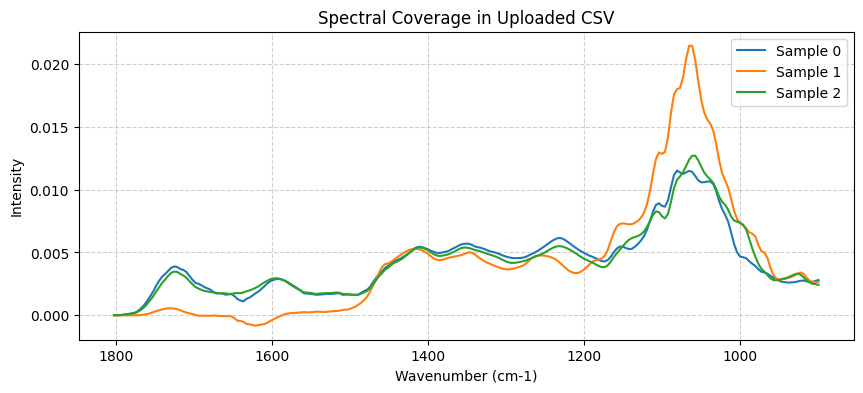

Current Range: 899.33 to 1802.56 cm-1
Note: Typical mid-IR spectra go from 400 to 4000 cm-1.


In [ ]:
import matplotlib.pyplot as plt

# Visualize the spectral coverage
plt.figure(figsize=(10, 4))
# Plot the first 3 samples to see the range
for i in range(min(3, X_raw_diag.shape[0])):
    plt.plot(wn_diag, X_raw_diag[i], label=f'Sample {i}')

plt.title('Spectral Coverage in Uploaded CSV')
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Intensity')
plt.gca().invert_xaxis() # Standard IR convention
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print(f"Current Range: {wn_diag.min():.2f} to {wn_diag.max():.2f} cm-1")
print("Note: Typical mid-IR spectra go from 400 to 4000 cm-1.")

In [ ]:
import json
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Use your existing training function to get the objects
# (Assuming 'run_ir_training_pipeline' is already defined in your notebook)
model, CLASSES, X_test, y_test, wavenumbers, history = run_ir_training_pipeline('Fruit_purees_FTIR.csv')

# 2. Save the Model
model.save("model.keras")

# 3. Create and Save the Scaler (matching your pipeline logic)
# Your pipeline used per-sample scaling, so we store a dummy scaler
# to keep the code structure, though the app will handle the math.
joblib.dump(MinMaxScaler(), "scaler.pkl")

# 4. Save the Config (The "Brain" of the App)
config = {
    "input_shape": int(X_test.shape[1]),
    "class_names": CLASSES,
    "wavenumbers": wavenumbers.tolist()
}

with open("config.json", "w") as f:
    json.dump(config, f)

print("✅ All 3 files generated! Download model.keras, scaler.pkl, and config.json now.")

✅ All 3 files generated! Download model.keras, scaler.pkl, and config.json now.


In [ ]:
import json
import joblib

# 1. Save the model
model.save("model.keras")

# 2. Save the scaler (using the scaler from your training pipeline)
# If your variable name is different, change it here
joblib.dump(scaler, "scaler.pkl")

# 3. Save the config (This tells the app what the labels are)
config = {
    "input_shape": X_train.shape[1],
    "class_names": CLASSES, # The list of labels like ['Apple', 'Plum', etc]
    "wavenumbers": wavenumbers.tolist() if 'wavenumbers' in locals() else None
}

with open("config.json", "w") as f:
    json.dump(config, f)

print("✅ DONE! Now download model.keras, scaler.pkl, and config.json from the Colab sidebar.")

✅ DONE! Now download model.keras, scaler.pkl, and config.json from the Colab sidebar.


In [ ]:
import json
import joblib

# 1. Save the new 983-point model
model.save("model.keras")

# 2. Save the new scaler
joblib.dump(scaler, "scaler.pkl")

# 3. Save the new config (crucial for the app to know it's now 983)
config = {
    "input_shape": 983,
    "class_names": CLASSES,
    "wavenumbers": wavenumbers.tolist()
}

with open("config.json", "w") as f:
    json.dump(config, f)